# The same pipeline on real measured forest

This runs the engine against **INPE PRODES** clear-cut deforestation for the Brazilian Legal
Amazon — 277 one-degree parcels, annual increments 2008–2023, collected by `tools/collect.mjs`
from the public TerraBrasilis WFS. Nothing on the measured side is modelled or simulated.

**Read the provenance split carefully.** The forest measured under and around each project is
real, including inside its own footprint. The *claimed baselines and credit volumes are
illustrative* — they describe no real project and name no real party. So every discrepancy below
is a real measurement of an invented claim: a valid exercise of the method, and not a finding
about anybody. `ResultProvenance.is_finding` is `False` for all of them and the engine says so in
its own output.

There is no Kariba REDD+ notebook because there is no data for it here. PRODES covers Brazil only;
a Zimbabwe project needs a control pool collected for its own region (Hansen/GFW), which is
Milestone 3–4 work. Producing a Kariba analysis from Amazon parcels would be fabrication.

In [1]:
import sys, dataclasses
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from app.config import DEFAULT_CONFIG
from app.services.data_source import validate_pool
from app.services.pipeline import ProjectDataError, run_project_analysis, run_backtest_series
from app.services.placebo_testing import run_placebo_suite
from app.services.sources.prodes_cells import ProdesCellSource

plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.25})

source = ProdesCellSource()
pool = source.load_pool()
projects = source.load_projects()
validate_pool(pool)

print(source.provenance.describe())
print(f'license   : {source.provenance.license}')
print(f'collected : {source.provenance.collected_at}')
print(f'caveat    : {source.provenance.note}')
print()
print(f'{len(pool)} parcels, {pool.resolution_note}, physical coherence checks passed')
print(f'{len(projects)} project records (measured footprints, illustrative claims)')

measured: INPE PRODES via TerraBrasilis WFS (deforestation, masks, boundaries); Open-Meteo (elevation, precipitation) (INPE. PRODES — Monitoramento do Desmatamento da Floresta Amazônica Brasileira por Satélite. terrabrasilis.dpi.inpe.br)
license   : INPE PRODES: open data. Open-Meteo: CC BY 4.0.
collected : 2026-08-21
caveat    : 1-degree parcels; bounding-box aggregation counts straddling polygons whole, so absolute loss rates are approximate. Rainfall is unmeasured throughout this collection.

277 parcels, 1 degree parcels, 2008-2023, physical coherence checks passed
7 project records (measured footprints, illustrative claims)


## Two footprints are refused, and that is the correct behaviour

The collector derives forest area by subtracting previously cleared land from a bounding box. A
large clearing polygon that straddles the boundary is counted whole on both sides, so for two of
these footprints the subtraction removes *more* than the footprint contains and the forest baseline
lands on zero.

Every loss ratio then divides by zero and returns 0.0%, which reads as a pristine, perfectly
protected forest rather than a broken denominator. That is the most dangerous direction for an
error to point in this tool, so the pipeline refuses these projects instead of reporting them.

In [2]:
config = DEFAULT_CONFIG.with_(
    uncertainty=dataclasses.replace(DEFAULT_CONFIG.uncertainty, n_bootstrap=400)
)

results, refused = {}, {}
for project in projects:
    try:
        results[project.project_id] = run_project_analysis(project, pool, config=config)
    except ProjectDataError as exc:
        refused[project.project_id] = (project, exc)

for project, exc in refused.values():
    print(f'REFUSED  {project.display_name}')
    print(f'         land {project.footprint.land_km2:.0f} km2, '
          f'prior clearing recorded as {project.footprint.prior_cleared_km2:.0f} km2 '
          f'-> forest baseline {project.footprint.forest_baseline_km2:.0f} km2')
print()
print(f'{len(results)} of {len(projects)} projects analysed')

REFUSED  Tucumã
         land 3063 km2, prior clearing recorded as 4256 km2 -> forest baseline 0 km2
REFUSED  Castanheira
         land 2389 km2, prior clearing recorded as 2747 km2 -> forest baseline 0 km2

5 of 7 projects analysed


In [3]:
print(f"{'project':13s} {'claimed':>8s} {'observed':>9s} {'counterfactual':>15s} {'95% interval':>16s} "
      f"{'supported':>10s} {'risk':>6s} {'conf':>9s}")
for pid, r in results.items():
    supported = '  n/a' if r.impact.supported_fraction is None else f'{r.impact.supported_fraction:9.0%}'
    interval = f'[{r.interval.lower:.1%}, {r.interval.upper:.1%}]'
    print(f'{r.project.display_name[:13]:13s} {r.impact.claimed_baseline:8.1%} '
          f'{r.impact.actual_loss:9.1%} {r.impact.counterfactual_loss:15.1%} {interval:>16s} '
          f'{supported:>10s} {r.risk.score:6.1f} {r.quality.confidence:>9s}')
print()
print('n/a means the project observed more loss than its own baseline predicted, so it claims no')
print('avoided deforestation over this window and there is no claim to apportion.')

project        claimed  observed  counterfactual     95% interval  supported   risk      conf
Aripuanã         12.7%     18.0%           20.8%   [15.3%, 27.8%]        n/a   22.3       LOW
Cachimbo         14.4%     14.8%           17.8%   [12.7%, 23.4%]        n/a   23.8       LOW
Juruena          14.4%      7.9%           15.8%   [10.2%, 31.3%]       100%    0.0       LOW
Guaporé          14.3%      4.9%            2.8%     [1.1%, 5.2%]         0%   80.4  MODERATE
Manicoré         17.2%     20.2%            6.6%    [3.7%, 13.7%]        n/a   34.1       LOW

n/a means the project observed more loss than its own baseline predicted, so it claims no
avoided deforestation over this window and there is no claim to apportion.


## One project in detail

Guaporé is the only one of these that reaches MODERATE confidence, so it is the one whose numbers
are worth reading rather than merely demonstrating the plumbing.

In [4]:
chosen = max(results.values(), key=lambda r: r.fit.effective_controls)
print(f'{chosen.project.name}  ({chosen.project.project_id})')
print(f'  start {chosen.project.start_year}, observed '
      f'{chosen.timing.effective_post.start}-{chosen.timing.effective_post.end}')
print()
print(f'  candidate pool  : {chosen.candidates.summary()}')
print(f'  shortlist       : {chosen.matching.summary()}')
print(f'  trajectory      : {chosen.trajectory_filter.summary()}')
print()
print(f'  pre-treatment RMSE {chosen.fit.pre_rmse:.5f}, '
      f'effective controls {chosen.fit.effective_controls:.2f}, '
      f'largest weight {chosen.fit.max_weight:.0%}')
print()
print('  contributing controls:')
for unit_id, weight in chosen.fit.contributing:
    unit = pool.by_id(unit_id)
    print(f'    {unit_id:12s} {weight:6.3f}  {unit.label}')
print()
print(f'  provenance: is_finding={chosen.provenance.is_finding}')
print(f'  {chosen.provenance.caveat}')
print()
for warning in chosen.quality.warnings:
    print('  ! ' + warning)

Vale do Guaporé REDD+  (PJ-4785)
  start 2016, observed 2016-2023

  candidate pool  : {'considered': 277, 'eligible': 70, 'rejected': 207, 'rejection_rate': 0.7473, 'reasons': {'protected': 203, 'leakage_buffer': 3, 'treated_or_host': 1}}
  shortlist       : {'considered': 70, 'matched': 66, 'rejected_on_distance': 4, 'caliper': 1.5, 'caliper_relaxed': False, 'caliper_note': '', 'worst_matched_distance': 1.4747}
  trajectory      : {'evaluated': 66, 'kept': 10, 'rejected': 56, 'relaxed_to_meet_minimum': True, 'note': 'Only 8 controls met the trajectory thresholds, below the floor of 10. The 10 closest by RMSE were kept instead. Pre-treatment fit and confidence are reduced accordingly.'}

  pre-treatment RMSE 0.00308, effective controls 2.63, largest weight 45%

  contributing controls:
    C-67_-11      0.448  Acrelândia
    C-71_-9       0.392  Feijó
    C-61_-15      0.160  Nova Lacerda

  provenance: is_finding=False
  The measured side of this comparison is real; the claimed basel

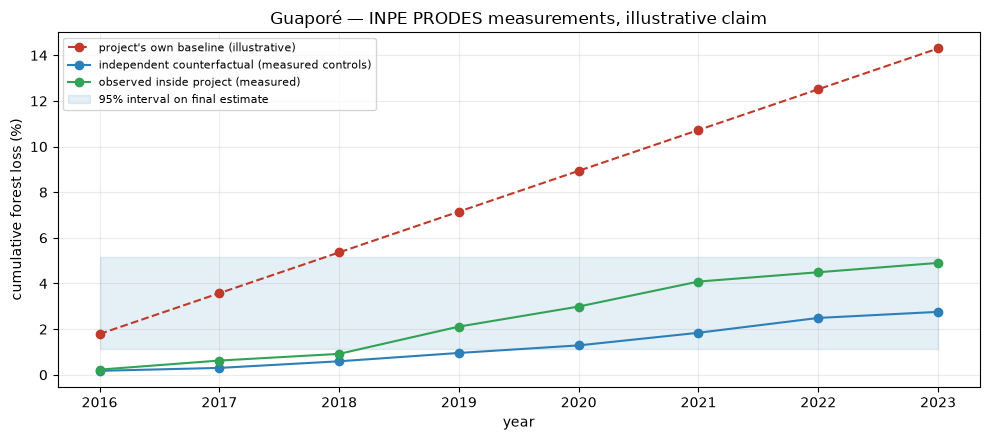

In [5]:
years = [row['year'] for row in chosen.timeline]
fig, ax = plt.subplots()
ax.plot(years, [row['claimed_loss'] * 100 for row in chosen.timeline], 'o--',
        color='#c0392b', label="project's own baseline (illustrative)")
ax.plot(years, [row['counterfactual_loss'] * 100 for row in chosen.timeline], 'o-',
        color='#2c7fb8', label='independent counterfactual (measured controls)')
ax.plot(years, [row['project_loss'] * 100 for row in chosen.timeline], 'o-',
        color='#31a354', label='observed inside project (measured)')
ax.fill_between(years, chosen.interval.lower * 100, chosen.interval.upper * 100,
                color='#2c7fb8', alpha=0.12, label='95% interval on final estimate')
ax.set_xlabel('year'); ax.set_ylabel('cumulative forest loss (%)')
ax.set_title(f'{chosen.project.display_name} — INPE PRODES measurements, illustrative claim')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Stage 18 — what the system would have said, year by year

Each row withholds everything after its cutoff and re-runs the whole pipeline.

In [6]:
rows = run_backtest_series(chosen.project, pool, cutoff_years=list(range(2017, 2024)))
print(f"{'as of':>6s} {'yrs':>4s} {'counterfactual':>15s} {'project':>9s} {'supported':>10s} "
      f"{'risk':>6s} {'confidence':>11s}")
for row in rows:
    if 'error' in row:
        print(f"{row['cutoff_year']:6d}  {row['error'][:60]}"); continue
    supported = '-' if row['supported_fraction'] is None else f"{row['supported_fraction']:.0%}"
    print(f"{row['cutoff_year']:6d} {row['years_observed']:4d} {row['counterfactual_loss']:15.2%} "
          f"{row['project_loss']:9.2%} {supported:>10s} {row['risk_score']:6.1f} "
          f"{row['confidence']:>11s}")

 as of  yrs  counterfactual   project  supported   risk  confidence
  2017    2           0.30%     0.62%         0%   64.3    MODERATE
  2018    3           0.59%     0.92%         0%   64.3    MODERATE
  2019    4           0.96%     2.11%         0%   64.3    MODERATE
  2020    5           1.29%     2.99%         0%   64.3    MODERATE
  2021    6           1.84%     4.08%         0%   64.3    MODERATE
  2022    7           2.49%     4.49%         0%   64.3    MODERATE
  2023    8           2.76%     4.90%         0%   64.3    MODERATE


## Stage 17 — the number that matters most

Everything above is an estimate of something unobservable. This is not. Sixty untreated parcels,
each given a pretend 2016 start, each predicted from data that stops in 2015, each scored against
what the satellite actually recorded afterwards.

Expect this to be much worse than the synthetic fixture. That is the point of running it.

In [7]:
suite = run_placebo_suite(
    pool, pseudo_start_years=[2016],
    config=DEFAULT_CONFIG.with_(
        uncertainty=dataclasses.replace(DEFAULT_CONFIG.uncertainty, n_bootstrap=120)
    ),
    max_units=60, min_forest_km2=500.0, include_bootstrap=True,
)
metrics = suite.metrics()
for key in ('n', 'n_failed', 'mae', 'rmse', 'bias', 'median_error',
            'p90_absolute_error', 'interval_coverage', 'mean_actual_loss',
            'mean_predicted_loss'):
    print(f'  {key:22s} {metrics[key]}')
print()
for line in metrics['interpretation']:
    print(' *', line)

  n                      60
  n_failed               0
  mae                    0.0424
  rmse                   0.10329
  bias                   -0.01883
  median_error           0.0001
  p90_absolute_error     0.10788
  interval_coverage      0.6167
  mean_actual_loss       0.08086
  mean_predicted_loss    0.06203

 * The estimator runs 1.883% low on average. A counterfactual biased low understates avoided deforestation and will report over-crediting even where none exists. Treat supported-fraction figures as conservative until this is corrected.
 * Only 62% of true outcomes fell inside the nominal 95% interval. The intervals are too narrow and every confidence statement built on them overstates precision.


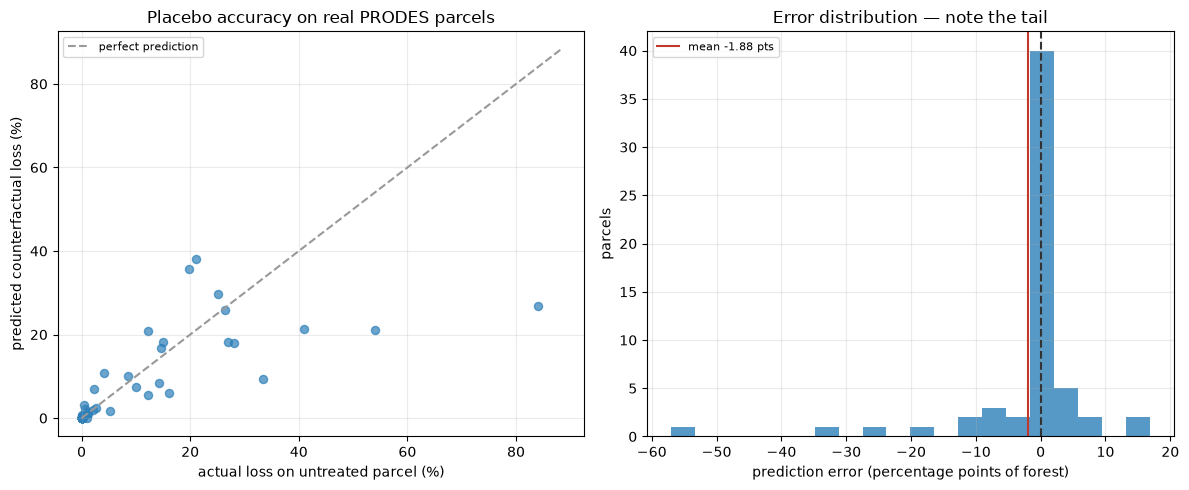

In [8]:
predicted = np.array([r.predicted_loss for r in suite.results]) * 100
actual = np.array([r.actual_loss for r in suite.results]) * 100
errors = predicted - actual

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lim = max(predicted.max(), actual.max()) * 1.05
axes[0].plot([0, lim], [0, lim], color='#999', ls='--', label='perfect prediction')
axes[0].scatter(actual, predicted, s=34, alpha=0.7, color='#2c7fb8')
axes[0].set_xlabel('actual loss on untreated parcel (%)')
axes[0].set_ylabel('predicted counterfactual loss (%)')
axes[0].set_title('Placebo accuracy on real PRODES parcels')
axes[0].legend(fontsize=8)

axes[1].hist(errors, bins=20, color='#2c7fb8', alpha=0.8)
axes[1].axvline(0, color='#333', ls='--')
axes[1].axvline(errors.mean(), color='#c0392b', label=f'mean {errors.mean():+.2f} pts')
axes[1].set_xlabel('prediction error (percentage points of forest)')
axes[1].set_ylabel('parcels')
axes[1].set_title('Error distribution — note the tail')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## What the real-data placebo says, and what follows from it

The median error is close to zero, so the estimator is not systematically wrong in the middle of
the distribution. But the mean absolute error is roughly **4 percentage points of forest cover**,
the RMSE is far larger than the MAE — a heavy tail, a handful of parcels badly mispredicted — and
interval coverage is about **62%** against a nominal 95%.

Three consequences, stated plainly:

1. **The confidence intervals are too narrow.** The bootstrap resamples donors and therefore sees
   only sensitivity to which parcels were available. Weight non-uniqueness and model
   misspecification are real and invisible to it. Placebo-based intervals — calibrating the
   interval width against this measured error distribution — are the correct fix and are not yet
   implemented.
2. **A 4-point mean error is the same order as the discrepancies being reported.** At this parcel
   resolution and pool size, the engine can support a screening claim ("this baseline deserves a
   closer look") and cannot support an adjudication ("this baseline is wrong by N points"). The
   engine's own confidence labels already say LOW for most of these projects.
3. **The likeliest cause is resolution.** One-degree parcels average over enormous internal
   variation, the donor pool is 72 eligible units, and effective control counts run 2–3. Finer
   units from Hansen/GFW tiles would give both a larger pool and less within-unit averaging. That
   is the next substantive improvement, ahead of any modelling change.

None of this is a reason to distrust the pipeline; it is the pipeline working. An estimator that
could not report its own error would have shipped these same numbers silently.